In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
%cd /content/drive/MyDrive/Colab Notebooks/TESI/MCMC_active_guided

/content/drive/MyDrive/Colab Notebooks/TESI/MCMC_active_guided


In [6]:
!pip install tinyDA

In [7]:
!pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 MB 5.6 MB/s eta 0:00:00


In [8]:
!pip install GPy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 11.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.12.0 which is incompatible.


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/TESI/MCMC_active_guided"

import sys
sys.path.append(f"{PROJECT_PATH}/utils")

from preprocessing import preprocessing

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import modelF

from modelF import coarse_model
from scipy.stats.qmc import LatinHypercube
from scipy.stats import norm

In [4]:
import numpy as np
from scipy.optimize import minimize


class ARDMatern52GaussianProcess:
    def __init__(self, reg=1e-2, init_scales=None):
        self.reg = reg
        self.scales = init_scales
        self.k_xx_inv = None
        self.x = None
        self.y = None

    def matern52_kernel(self, a, b, scales=None):
        a = np.atleast_2d(a)
        b = np.atleast_2d(b)
        if scales is None:
            scales = self.scales
        scales = np.atleast_1d(scales).reshape(1, 1, -1)

        diff = a[:, None, :] - b[None, :, :]
        dists_sq = np.sum(scales * diff**2, axis=2)
        dists = np.sqrt(dists_sq + 1e-12)

        sqrt5_d = np.sqrt(5.0 * dists_sq)
        term = 1 + sqrt5_d + (5.0 / 3.0) * dists_sq
        return term * np.exp(-np.sqrt(5.0) * dists)

    def matern52_kernel_incr_inv(self, B, C, D):
        S = D - C @ self.k_xx_inv @ B
        temp = np.linalg.inv(S)

        block1 = self.k_xx_inv + self.k_xx_inv @ B @ temp @ C @ self.k_xx_inv
        block2 = -self.k_xx_inv @ B @ temp
        block3 = -temp @ C @ self.k_xx_inv
        block4 = temp

        top = np.concatenate((block1, block2), axis=1)
        bottom = np.concatenate((block3, block4), axis=1)
        return np.concatenate((top, bottom), axis=0)

    def neg_log_marginal_likelihood(self, log_scales):
        scales = np.exp(log_scales)
        K = self.matern52_kernel(self.x, self.x, scales) + self.reg * np.eye(self.x.shape[0])
        try:
            L = np.linalg.cholesky(K)
            alpha = np.linalg.solve(L.T, np.linalg.solve(L, self.y))
            nlml = (
                0.5 * self.y.T @ alpha +
                np.sum(np.log(np.diag(L))) +
                0.5 * self.x.shape[0] * np.log(2 * np.pi)
            )
            return nlml.ravel()[0]
        except np.linalg.LinAlgError:
            return 1e6

    def fit(self, x, y, optimize_scales=True):
        x, y = np.atleast_2d(x), np.atleast_2d(y)

        if self.scales is None:
            self.scales = np.ones(x.shape[1])

        if self.k_xx_inv is None:
            # First training step
            self.x = x
            self.y = y

            if optimize_scales:
                res = minimize(self.neg_log_marginal_likelihood,
                               x0=np.log(self.scales),
                               method='L-BFGS-B',
                               bounds=[(-5, 5)] * x.shape[1])
                self.scales = np.exp(res.x)

            K = self.matern52_kernel(x, x, self.scales) + self.reg * np.eye(x.shape[0])
            self.k_xx_inv = np.linalg.inv(K)
        else:
            # Online update via Woodbury identity
            B = self.matern52_kernel(self.x, x, self.scales)
            C = B.T
            D = self.matern52_kernel(x, x, self.scales) + self.reg * np.eye(x.shape[0])
            self.k_xx_inv = self.matern52_kernel_incr_inv(B, C, D)

            print(np.linalg.cond(self.k_xx_inv))
            self.x = np.vstack((self.x, x))
            self.y = np.vstack((self.y, y))

        return self

    def predict(self, x_predict):
        x_predict = np.atleast_2d(x_predict)
        k = self.matern52_kernel(x_predict, self.x, self.scales)
        mu_hat = k @ self.k_xx_inv @ self.y
        sigma_hat = 1 - np.sum(k @ self.k_xx_inv * k, axis=1)
        sigma_hat = np.maximum(sigma_hat, 0.0)
        return mu_hat.ravel(), np.sqrt(sigma_hat)

In [5]:
nsamples_train = 50
nsamples = 1000

num_dimensions = 3  # Number of parameters
seed = 449
sampler = LatinHypercube(d=3, seed=seed)
lhs_samples = sampler.random(n=nsamples)

# Scale the samples to the desired ranges for each parameter
param_ranges = [(0.1, 0.5), (-0.5, 0.5), (29, 31)]  # Define ranges for each parameter
random_parameters = lhs_samples.copy()
for i, (low, high) in enumerate(param_ranges):
    random_parameters[:, i] = low + (high - low) * lhs_samples[:, i]

In [6]:
# 1. Centro i dati
X_train = np.array([random_parameters[i] for i in range(nsamples_train)])
X_test = np.array([random_parameters[i] for i in range(nsamples_train, nsamples)])
Y_train = np.array([coarse_model(X_train[i]) for i in range(nsamples_train)])  # (640, 150)
Y_test = np.array([coarse_model(X_test[i]) for i in range(nsamples-nsamples_train)])  # (640, 150)

X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)
X_train_centered = (X_train - X_train_mean)/X_train_std
X_test_centered = (X_test - X_train_mean)/X_train_std

Y_min = np.min(Y_train)
Y_max = np.max(Y_train)
Y_std = Y_max - Y_min
Y_centered = (Y_train - Y_min)/Y_std
Y_centered_test = (Y_test - Y_min)/Y_std

# 2. SVD
U, s, VT = np.linalg.svd(Y_centered.T, full_matrices=False)

print(U.shape)
# 3. Scegli il rank
r = 5 # puoi cambiare
Z_r = U[:,:r]
s_r = s[:r]
V_r = VT[:r, :]          # (r, 150)

# 4. Ricostruzione del segnale i-esimo
i = 7 # scegli quale segnale visualizzare
y_true = Y_centered_test[i, :]               # segnale originale centrato
y_reconstructed = Z_r @ Z_r.T @ y_true.T       # ricostruzione centrata

# 5. Aggiungo la media a entrambi
y_true *= 1
y_reconstructed *= 1
y_true += 0
y_reconstructed += 0

print(np.sqrt(np.mean((Y_centered.T -  Z_r @ Z_r.T @ Y_centered.T  ) ** 2)))

np.savez(f"data/gp_svd_decomposition_{nsamples_train}.npz",
         Z_r=Z_r,
         V_r=V_r,
         s_r=s_r,
         Y_min=Y_min,
         Y_centered=Y_centered,
         Y_std=Y_std,
         X_mean=X_train_mean,
         X_std=X_train_std)

(150, 50)
7.975369203525634e-05


In [7]:
r = 5
V_target = (s_r[np.newaxis,:] * V_r.T)  # (640, r)
print("V_r", V_r.shape)
GP_models = []

for j in range(Z_r.shape[1]):  # per ogni componente ridotta (z_j)
    v_j = V_target[:,j].reshape(-1, 1)  # Output da modellare
    print("v_j", v_j.shape)
    model = ARDMatern52GaussianProcess(init_scales=np.array([1.0,1.0,0.01]),reg=1e-4)
    model.fit(X_train_centered, v_j,optimize_scales=True)
    GP_models.append(model)

model.predict(X_test_centered)[0].shape

V_r (5, 50)
v_j (50, 1)
v_j (50, 1)
v_j (50, 1)
v_j (50, 1)
v_j (50, 1)


(950,)

In [8]:
from scipy.stats import norm

def compute_log_likelihood_from_gp(theta, GP_models, Z_r, Y_std, Y_min, X_mean, X_std, y_obs, sigma):
    """
    Calcola log-likelihood usando la ricostruzione da GP+SVD
    """
    # Standardizza theta
    theta_centered = (theta - X_mean) / X_std
    theta_centered = theta_centered.reshape(1, -1)

    # Predici componenti ridotte z_i e varianza associata
    z_pred = []
    z_std = []

    for model in GP_models:
        mu, std = model.predict(theta_centered)
        z_pred.append(mu.item())
        z_std.append(std.item())

    z_pred = np.array(z_pred)       # (r,)
    z_std = np.array(z_std)         # (r,)

    # Ricostruisci y_pred
    y_pred = Y_std * (Z_r @ z_pred) + Y_min  # (150,)

    # Log-likelihood gaussiana
    residual = y_obs - y_pred
    logL = -0.5 * np.sum((residual / sigma)**2)

    return logL, z_std


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri principali
N_total = 1000
gamma_v = 0.04
gamma_L = 2.5
Nb = 50
s = 0.1

# Inizializzazione random
rng = np.random.default_rng(42)

def metropolis_acceptance(logL_old, logL_new):
    return min(1.0, np.exp(logL_new - logL_old))

def active_learning_gp_with_updates(GP_models, Z_r, Y_std, Y_min, X_mean, X_std,
                                    y_obs, sigma, theta_start, cov_matrix,
                                    compute_log_likelihood_from_gp):
    theta_chain = [theta_start]
    n = 0
    r = len(GP_models)
    retrain_counter = [0 for _ in range(r)]
    std_history = []

    while n < N_total:
        theta_n = theta_chain[-1]

        # Proposta RWM
        z = rng.multivariate_normal(mean=np.zeros(cov_matrix.shape[0]), cov=cov_matrix, size=1)
        theta_star = theta_n + s * z[0]

        # GP prediction con SVD
        theta_star_centered = (theta_star - X_mean) / X_std
        z_pred = []
        z_std = []

        for model in GP_models:
            mu_j, std_j = model.predict(theta_star_centered.reshape(1, -1))
            z_pred.append(mu_j.item())
            z_std.append(std_j.item())

        z_pred = np.array(z_pred)
        z_std = np.array(z_std)

        # Ricostruzione segnale
        y_pred = Y_std * (Z_r @ z_pred) + Y_min

        # Varianza predittiva nel tempo
        cov_y = Z_r @ np.diag(z_std**2) @ Z_r.T
        y_std = np.sqrt(np.diag(cov_y)) * Y_std
        std_scalar = np.mean(y_std)
        std_history.append(std_scalar)

        print(f"[Iter {n}] GP std media = {std_scalar:.4f} (γ_v = {gamma_v})")

        # Calcolo log-likelihood
        if std_scalar < gamma_v:
            logL_star = -0.5 * np.sum(((y_obs - y_pred)/sigma)**2 + np.log(2 * np.pi * sigma**2))
        else:
            # Calcola nuova log-likelihood dal modello coarse
            y_star = y_pred
            logL_star, z_std_new = compute_log_likelihood_from_gp(
                theta_star, GP_models, Z_r, Y_std, Y_min, X_mean, X_std, y_obs, sigma
            )

            # Aggiorna ogni GP model
            for j, model in enumerate(GP_models):
                L_old = -model.neg_log_marginal_likelihood(np.log(model.scales))
                v_j_star = z_pred[j].reshape(1, -1)
                model.fit(theta_star_centered, v_j_star, optimize_scales=False)
                L_new = -model.neg_log_marginal_likelihood(np.log(model.scales))
                if abs(L_new / L_old) > gamma_L and retrain_counter[j] < Nb:
                    model.fit(model.x, model.y, optimize_scales=True)
                    retrain_counter[j] += 1

        # Acceptance step
        bound_1 = (0.1 < theta_star[0] < 0.6)
        bound_2 = (-1.0 < theta_star[1] < 1.0)
        bound_3 = (29.0 < theta_star[2] < 31.0)
        within_bounds = bound_1 * bound_2 * bound_3

        # Calcolo logL corrente
        theta_n_centered = (theta_n - X_mean) / X_std
        z_pred_n = []
        for model in GP_models:
            mu_j, _ = model.predict(theta_n_centered.reshape(1, -1))
            z_pred_n.append(mu_j.item())
        z_pred_n = np.array(z_pred_n)
        y_pred_n = Y_std * (Z_r @ z_pred_n) + Y_min
        logL_n = -0.5 * np.sum(((y_obs - y_pred_n)/sigma)**2 + np.log(2 * np.pi * sigma**2))
        logL_n *= within_bounds

        alpha = metropolis_acceptance(logL_n, logL_star)

        if rng.uniform() < alpha:
            theta_chain.append(theta_star)
        else:
            theta_chain.append(theta_n)

        n += 1

    # Plot std evoluzione
    plt.plot(std_history)
    plt.title("Evoluzione della deviazione standard media del GP")
    plt.xlabel("Iterazione")
    plt.ylabel("GP std media")
    plt.grid(True)
    plt.show()

    return np.array(theta_chain)



In [12]:
theta_true = np.array([0.3, 0.1, 30.2])
y_obs = coarse_model(theta_true)
sigma = 0.5

In [13]:
from scipy.optimize import least_squares

def objective_function(theta):
    y_pred = coarse_model(theta)
    return y_pred - y_obs

theta0_guess = np.mean(X_train, axis=0)

result = least_squares(objective_function, theta0_guess, bounds=([0.1, -0.5, 29], [0.5, 0.5, 31]))

theta_start = result.x
cov_matrix = np.linalg.inv(result.jac.T @ result.jac)

print(theta_start)
print(cov_matrix)

[ 0.3  0.1 30.2]
[[ 1.43622506e-04 -2.05926967e-05  1.53841450e-02]
 [-2.05926967e-05  1.29735696e-05 -4.90472417e-03]
 [ 1.53841450e-02 -4.90472417e-03  2.39036957e+00]]


[Iter 0] GP std media = 0.7899 (γ_v = 0.04)
273942.7763746995
486550.47709148785
504521.2220186648
504521.2220186648
504521.2220186648
[Iter 1] GP std media = 0.4412 (γ_v = 0.04)
284361.49590883177
496745.8352287777
514642.3055561361
514642.3055561361
514642.3055561361
[Iter 2] GP std media = 0.2876 (γ_v = 0.04)
366957.552316293
510105.5388555704
525525.3545060152
525525.3545060152
525525.3545060152
[Iter 3] GP std media = 0.2368 (γ_v = 0.04)
376041.9633132629
520453.38882094575
535984.1834923292
535984.1834923292
535984.1834923292
[Iter 4] GP std media = 0.2010 (γ_v = 0.04)
385051.3456548418
530707.1255340326
546265.6614197742
546265.6614197742
546265.6614197742
[Iter 5] GP std media = 0.1878 (γ_v = 0.04)
394124.1669892015
540967.2914486526
556796.0392180732
556796.0392180732
556796.0392180732
[Iter 6] GP std media = 0.1923 (γ_v = 0.04)
403259.92059478804
551315.0123347061
567325.6761624139
567325.6761624139
567325.6761624139
[Iter 7] GP std media = 0.1630 (γ_v = 0.04)
412451.46480445

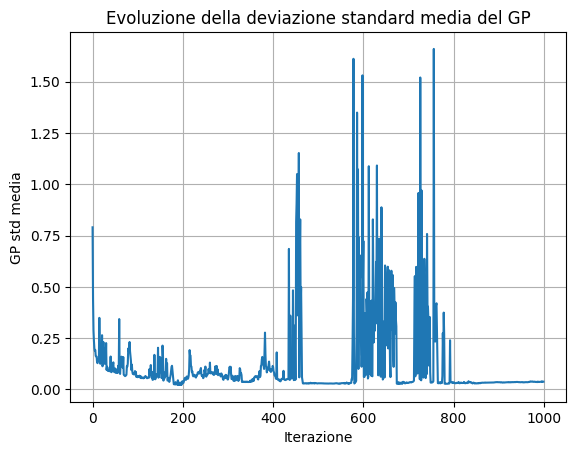

In [17]:
theta_chain = active_learning_gp_with_updates(
    GP_models=GP_models,
    Z_r=Z_r,
    X_mean=X_train_mean,
    X_std=X_train_std,
    Y_min=Y_min,
    Y_std=Y_std,
    y_obs=y_obs,
    sigma=sigma,
    theta_start=theta_start,
    cov_matrix=cov_matrix,
    compute_log_likelihood_from_gp=compute_log_likelihood_from_gp
)


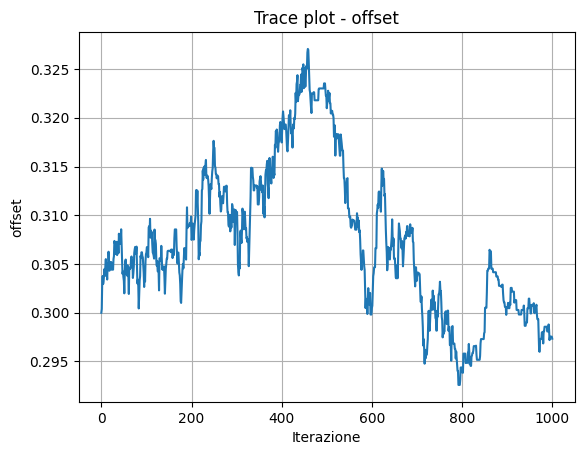

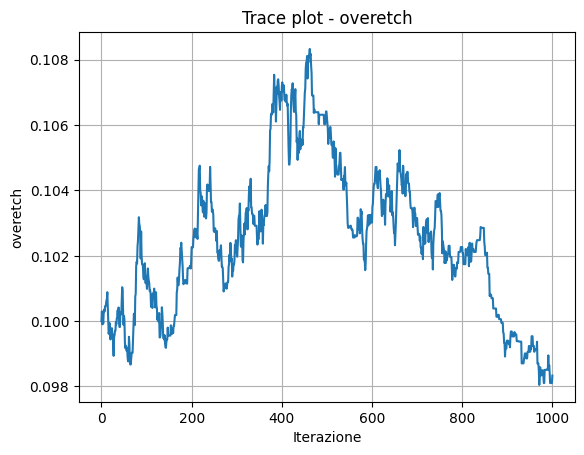

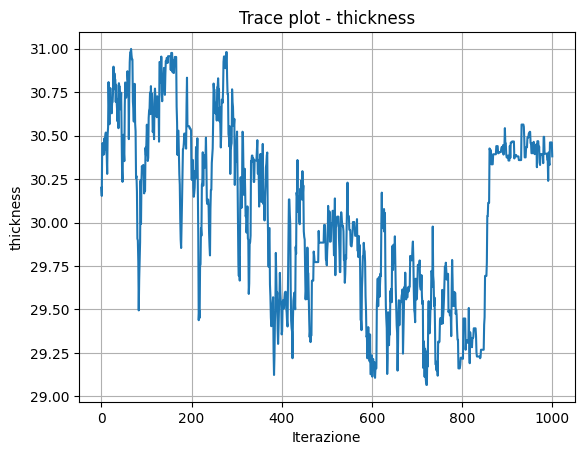

In [18]:
theta_chain = np.array(theta_chain)  # assicurati sia array (T, d)
param_names = ['offset', 'overetch', 'thickness']  # cambia se serve

for i in range(theta_chain.shape[1]):
    plt.figure()
    plt.plot(theta_chain[:, i])
    plt.title(f"Trace plot - {param_names[i]}")
    plt.xlabel("Iterazione")
    plt.ylabel(param_names[i])
    plt.grid(True)
    plt.show()

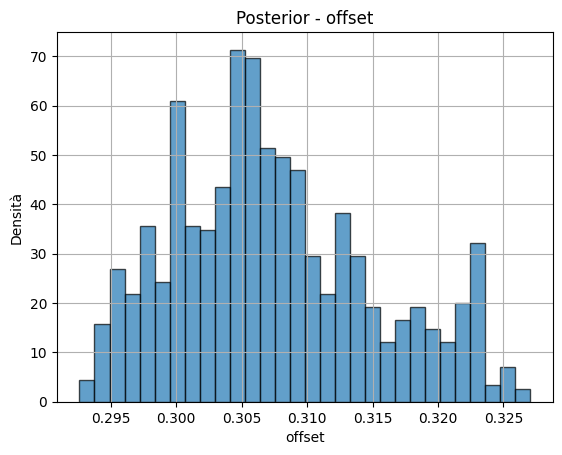

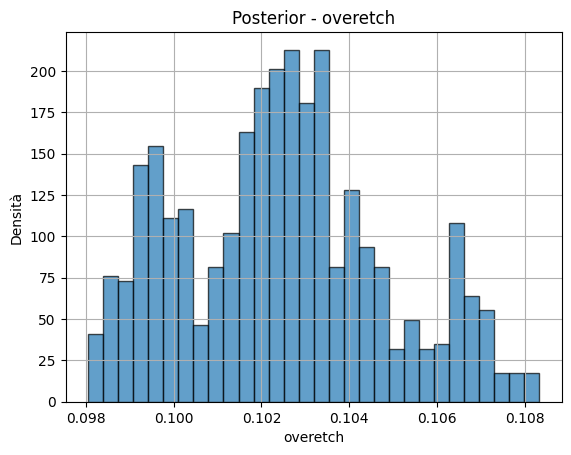

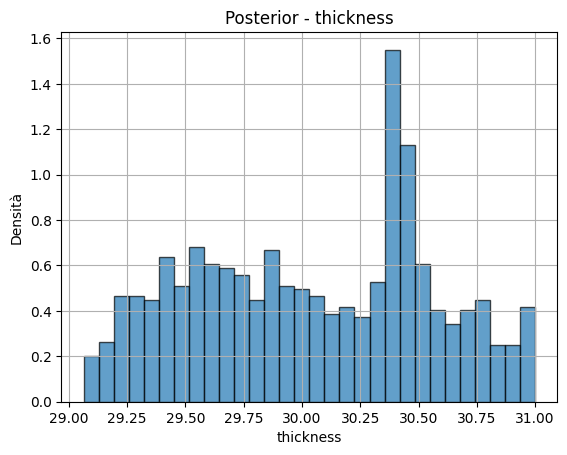

In [19]:
for i in range(theta_chain.shape[1]):
    plt.figure()
    plt.hist(theta_chain[:, i], bins=30, density=True, edgecolor='k', alpha=0.7)
    plt.title(f"Posterior - {param_names[i]}")
    plt.xlabel(param_names[i])
    plt.ylabel("Densità")
    plt.grid(True)
    plt.show()

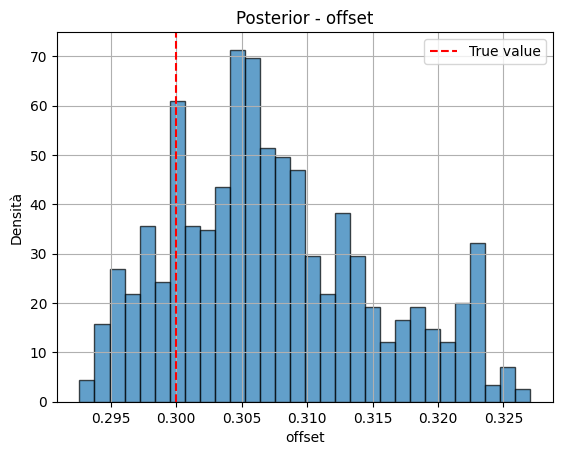

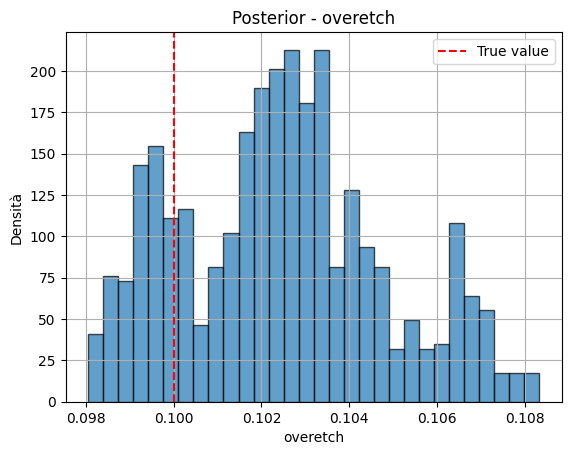

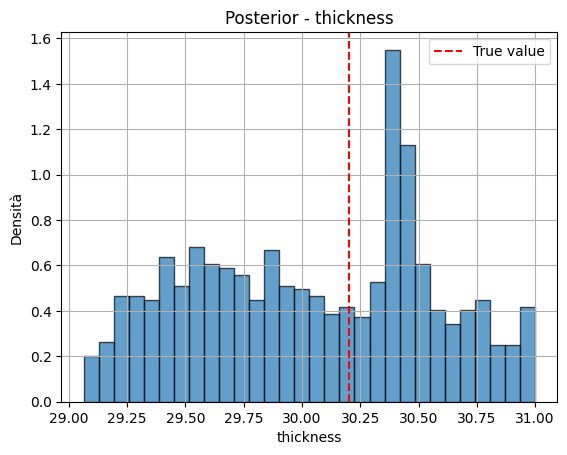

In [20]:
theta_true = np.array([0.3, 0.1, 30.2])  # esempio
for i in range(theta_chain.shape[1]):
    plt.figure()
    plt.hist(theta_chain[:, i], bins=30, density=True, edgecolor='k', alpha=0.7)
    plt.axvline(theta_true[i], color='red', linestyle='--', label='True value')
    plt.title(f"Posterior - {param_names[i]}")
    plt.xlabel(param_names[i])
    plt.ylabel("Densità")
    plt.legend()
    plt.grid(True)
    plt.show()
